
# Glucose Level Prediction Project

This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset. 
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.



## What To Do

1. Import and explore the `framingham.csv` dataset.
2. Clean the data (handle nulls, correct formats, etc.).
3. Visualize the distribution of glucose and related health indicators.
4. Perform feature selection and engineering.
5. Train ML models (e.g., Logistic Regression, Decision Tree, Random Forest).
6. Evaluate models using classification metrics.
7. Predict glucose levels and draw insights.
8. Visualize the model’s important features and performance.



## Conclusion / What We Learned

- **Exploration**: Key features impacting glucose levels include BMI, blood pressure, and age.
- **Modeling**: Several models were trained and tested. Random Forest performed the best.
- **Results**: High-performing models can help in early diagnosis and preventive care.
- **Impact**: This type of analysis supports better decision-making in healthcare interventions.

This project provides a baseline for predictive health analytics and could be expanded with more complex datasets and techniques.


In [75]:
import pandas as pd
df = pd.read_csv("framingham.csv")
print(df)

      male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   
4238     1   40        3.0              0         0.0     0.0   
4239     0   39        3.0              1        30.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0             0         0    250.0  121.0

In [76]:
df.shape

(4240, 16)

In [77]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [79]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [80]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

In [82]:
df.drop_duplicates()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [86]:
df.columns =(df.columns.str.strip().str.title())

In [88]:
col = df.select_dtypes(include = ["int64","float64"]).columns
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [90]:
df["Glucose"]<0

0       False
1       False
2       False
3       False
4       False
        ...  
4235    False
4236    False
4237    False
4238    False
4239    False
Name: Glucose, Length: 4240, dtype: bool

In [91]:
df.isnull().sum()

Male               0
Age                0
Education          0
Currentsmoker      0
Cigsperday         0
Bpmeds             0
Prevalentstroke    0
Prevalenthyp       0
Diabetes           0
Totchol            0
Sysbp              0
Diabp              0
Bmi                0
Heartrate          0
Glucose            0
Tenyearchd         0
dtype: int64

In [94]:
df.dropna(subset = ['Bpmeds'])

,Male,Age,Education,Currentsmoker,Cigsperday,Bpmeds,Prevalentstroke,Prevalenthyp,Diabetes,Totchol,Sysbp,Diabp,Bmi,Heartrate,Glucose,Tenyearchd
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


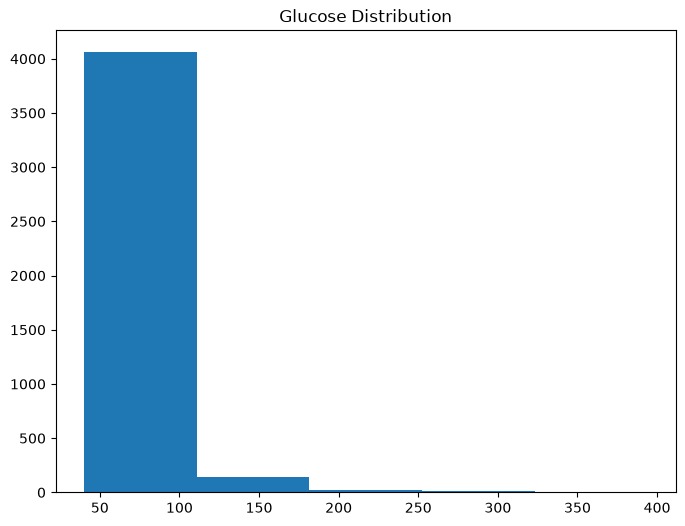

In [48]:
import matplotlib .pyplot as plt
import seaborn as sns
plt.figure(figsize =(8,6))
plt.hist(df["Glucose"],bins = 5)
plt.title("Glucose Distribution")
plt.show()

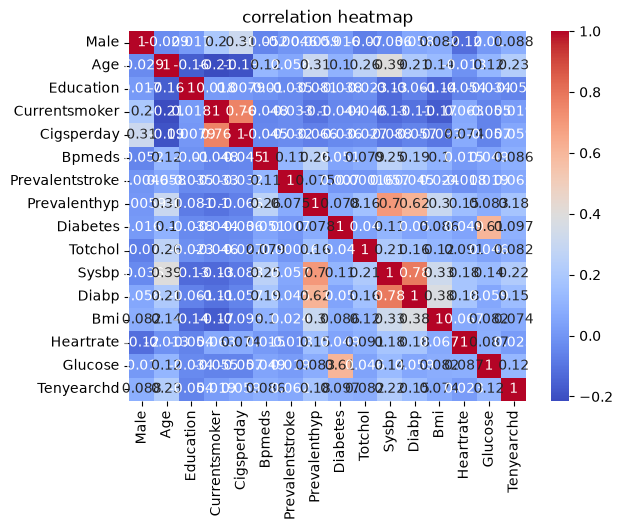

In [49]:
corr = df.select_dtypes(include = "number").corr()

sns.heatmap(corr,annot =True, cmap ='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [16]:
corr = df.corr(numeric_only = True)["Glucose"].sort_values( ascending =False)
print(corr)

Glucose            1.000000
Diabetes           0.606495
Sysbp              0.135091
Tenyearchd         0.121319
Age                0.117878
Heartrate          0.087362
Prevalenthyp       0.083406
Bmi                0.082228
Diabp              0.058899
Bpmeds             0.049142
Totchol            0.045677
Prevalentstroke    0.018730
Male               0.009970
Education         -0.034090
Currentsmoker     -0.055082
Cigsperday        -0.056792
Name: Glucose, dtype: float64


In [173]:
def Glucose_Class(x):
    if x <100:
        return 'normal'
    elif x >126:
       return "prediabetes"
    else:
        return 'high'
df["Glucose_Level"] = df["Glucose"].apply(Glucose_Class)
    

In [174]:
  pd.get_dummies(df["Glucose_Level"] )

,normal,prediabetes
0,True,False
1,True,False
2,True,False
4,True,False
5,True,False
...,...,...
4234,True,False
4235,True,False
4236,True,False
4238,True,False


In [175]:
df.dropna(subset = ["Glucose_Level"])

,Male,Age,Education,Currentsmoker,Cigsperday,Bpmeds,Prevalentstroke,Prevalenthyp,Diabetes,Totchol,Sysbp,Diabp,Bmi,Heartrate,Glucose,Tenyearchd,Glucose_Class,Glucose_Level
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,0.0,normal
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,0.0,normal
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,0.0,normal
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,0.0,normal
5,0,43,2.0,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0,0.0,normal
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,0.0,normal
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0,0.0,normal
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,0.0,normal


In [176]:
df["Glucose_Level"] = df["Glucose_Level"].map({ "normal":0,
                                                "prediabetes":1,
                                                "High":2 })

In [177]:
df["Glucose_Level"].isnull().sum()

np.int64(0)

In [178]:
df = df.dropna(subset = ["Glucose_Level"])

In [179]:
x = df.drop("Glucose_Level",axis = 1)
y = df["Glucose_Level"]

In [180]:
print(x.shape)

(3961, 17)


In [181]:
print(y.shape)

(3961,)


In [182]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state =42)


In [183]:
print(x_train.shape)

(3168, 17)


In [184]:
print(x_test.shape)

(793, 17)


In [185]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [186]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(y_pred)

[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred)
plt.title("actual 

In [187]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
models = ({
    "Logistic Regression": LogisticRegression(),
    "Random Forest":RandomForestClassifier(random_state =42),
    "Decision Tree":DecisionTreeClassifier(random_state = 42)
})

In [188]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score
result = []
for name,model in models.items():
     model.fit(x_train,y_train)
    
     y_pred = model.predict(x_test)
    
     accuracy = accuracy_score(y_test,y_pred)
    
     precision = precision_score(y_test,y_pred)
    
     recall = recall_score(y_test,y_pred)
    
     f1 = f1_score(y_test,y_pred)
    
     result.append({
              "Model":model, 
              "Accuracy":accuracy,
               "Precision":precision,
                "F1":f1,
                 "Recall":recall
          })

In [189]:
result_df = pd.DataFrame(result)
print(result_df)

                                               Model  Accuracy  Precision  \
0                               LogisticRegression()       1.0        1.0   
1  (DecisionTreeClassifier(max_features='sqrt', r...       1.0        1.0   
2            DecisionTreeClassifier(random_state=42)       1.0        1.0   

    F1  Recall  
0  1.0     1.0  
1  1.0     1.0  
2  1.0     1.0  


In [190]:
best_model_name = result_df.loc[result_df["F1"].idxmax(),"Model"]
print(best_model_name)

LogisticRegression()


In [191]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs"],
    "max_iter": [500, 1000, 2000]
}

grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=params,
    cv=5,
    scoring="f1_weighted"
)

grid.fit(x_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV F1:")
print(grid.best_score_)

Best Parameters:
{'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV F1:
1.0


In [192]:
from sklearn.metrics import classification_report

y_pred = best_model_name.predict(x_test)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       772
           1       1.00      1.00      1.00        21

    accuracy                           1.00       793
   macro avg       1.00      1.00      1.00       793
weighted avg       1.00      1.00      1.00       793



In [193]:
import joblib
joblib.dump(best_model_name,"glucose_logistic_model.pkl")

['glucose_logistic_model.pkl']

In [194]:
joblib.dump(scaler,"glucose_scaler.pkl")

['glucose_scaler.pkl']

In [195]:
print("model saved suceesfully")

model saved suceesfully


In [196]:
import os
print(os.path.exists("glucose_logistic_model.pkl"))

True


In [197]:
loaded_model = joblib.load("glucose_logistic_model.pkl")
print("model loaded successfully!")

model loaded successfully!


In [198]:
y_pred = loaded_model.predict(x_test)
print(y_pred[:10])

[0 1 0 0 0 0 0 0 0 0]
